# Coral Classification: Data Exploration and Preprocessing
- dataset loading
- class/distribution exploration
- sample image visualization
- preprocessing and generator creation

In [16]:
!pip install -q kagglehub scikit-learn seaborn
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aneeshdighe/corals-classification")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'corals-classification' dataset.
Path to dataset files: /kaggle/input/corals-classification


In [18]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SUBSET_SIZE = 3000  # target train size
SEED = 42
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# use downloaded dataset path
dataset = Path("/root/.cache/kagglehub/datasets/aneeshdighe/corals-classification/versions/1")

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [19]:
# resolve actual folder containing Training/Validation/Testing
data_directory = dataset
candidate = dataset / "Bleached Corals and Healthy Corals Classification"
if candidate.exists():
    data_directory = candidate

training = data_directory / "Training"
validation = data_directory / "Validation"
testing = data_directory / "Testing"

if not all(p.exists() for p in [training, validation, testing]):
    raise FileNotFoundError("Could not find Training/Validation/Testing folders at DATASET_ROOT")

print("Train:", training)
print("Valid:", validation)
print("Test:", testing)

Train: /root/.cache/kagglehub/datasets/aneeshdighe/corals-classification/versions/1/Bleached Corals and Healthy Corals Classification/Training
Valid: /root/.cache/kagglehub/datasets/aneeshdighe/corals-classification/versions/1/Bleached Corals and Healthy Corals Classification/Validation
Test: /root/.cache/kagglehub/datasets/aneeshdighe/corals-classification/versions/1/Bleached Corals and Healthy Corals Classification/Testing


In [25]:
# Build a dataframe with two columns:
# - filepath: full path to each image
# - label: class folder name (bleached_corals / healthy_corals)
def make_image_df(root_dir):
    rows = []

    # Find class folders inside root_dir
    class_names = sorted([p.name for p in root_dir.iterdir() if p.is_dir()])

    # Walk through each class folder and collect image paths
    for class_name in class_names:
        class_dir = root_dir / class_name
        for fp in class_dir.iterdir():
            if fp.suffix.lower() in IMAGE_EXTS:
                rows.append((str(fp), class_name))

    # Shuffle so data order is random but reproducible (SEED)
    df = pd.DataFrame(rows, columns=["filepath", "label"])
    return df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)


# Take a smaller training subset while preserving class ratio
# (stratified = same healthy/bleached proportion as original)
def take_stratified_subset(df, n_samples):
    if n_samples is None or n_samples >= len(df):
        return df.reset_index(drop=True)

    subset, _ = train_test_split(
        df,
        train_size=n_samples,
        stratify=df["label"],
        random_state=SEED,
    )
    return subset.reset_index(drop=True)


# Convert train/valid/test dataframes into Keras generators
# so the model can read images in batches during training/evaluation
def make_generators(train_df, valid_df, test_df):
    # Keep class order consistent across all splits
    classes = sorted(train_df["label"].unique())

    # Train generator gets augmentation to improve generalization
    train_aug = ImageDataGenerator(
        rescale=1./255,  # normalize pixel values
        horizontal_flip=True,
        rotation_range=20,
        zoom_range=0.15,
        width_shift_range=0.1,
        height_shift_range=0.1,
    )

    # Validation/Test generators should NOT augment images
    eval_gen = ImageDataGenerator(rescale=1./255)  # normalize only

    # Training generator: shuffled batches + augmentation
    train_gen = train_aug.flow_from_dataframe(
        train_df,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        classes=classes,
        shuffle=True,
        seed=SEED,
    )

    # Validation generator: no shuffle for stable evaluation
    valid_gen = eval_gen.flow_from_dataframe(
        valid_df,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        classes=classes,
        shuffle=False,
    )

    # Test generator: no shuffle for final metrics/reporting
    test_gen = eval_gen.flow_from_dataframe(
        test_df,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        classes=classes,
        shuffle=False,
    )

    return train_gen, valid_gen, test_gen

# Data Exploration

Image counts by split:
Train: 7384
Valid: 985
Test : 923

Train class counts:
label
bleached_corals    3880
healthy_corals     3504
Name: count, dtype: int64

Validation class counts:
label
healthy_corals     500
bleached_corals    485
Name: count, dtype: int64

Test class counts:
label
bleached_corals    485
healthy_corals     438
Name: count, dtype: int64


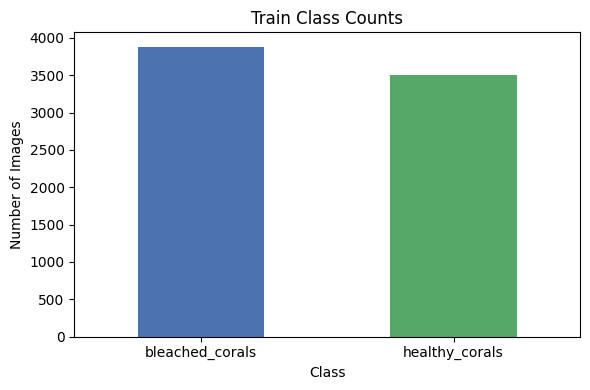

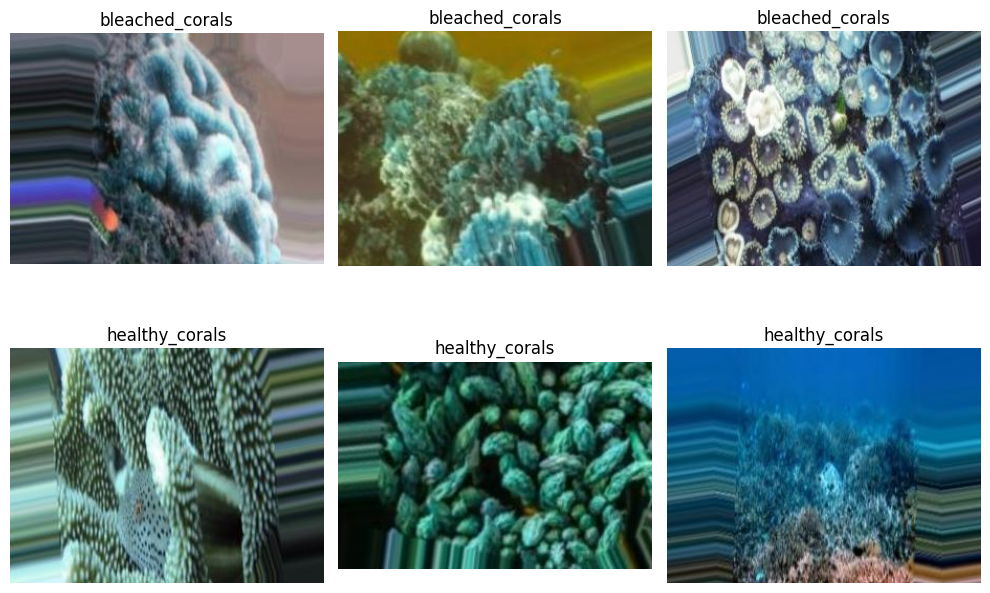

In [33]:
# load full metadata for exploration
train_df_full = make_image_df(training)
valid_df_full = make_image_df(validation)
test_df_full = make_image_df(testing)

print("Image counts by split:")
print(f"Train: {len(train_df_full)}")
print(f"Valid: {len(valid_df_full)}")
print(f"Test : {len(test_df_full)}")

print("\nTrain class counts:")
print(train_df_full["label"].value_counts())

print("\nValidation class counts:")
print(valid_df_full["label"].value_counts())

print("\nTest class counts:")
print(test_df_full["label"].value_counts())

# simple class count plot
train_df_full["label"].value_counts().sort_index().plot(kind="bar", figsize=(6, 4), color=["#4C72B0", "#55A868"])
plt.title("Train Class Counts")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# sample images
sample_rows = train_df_full.sample(n=min(6, len(train_df_full)), random_state=SEED).reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.flatten()
for i, row in sample_rows.iterrows():
    axes[i].imshow(plt.imread(row["filepath"]))
    axes[i].set_title(row["label"])
    axes[i].axis("off")
for j in range(len(sample_rows), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

# Preprocessing

In [27]:
# keep all validation/test images, but use only ~3000 training images
train_df = take_stratified_subset(train_df_full, SUBSET_SIZE)
valid_df = valid_df_full.copy()
test_df = test_df_full.copy()

print(f"Training subset size: {len(train_df)}")
print(train_df["label"].value_counts(normalize=True).rename("train_ratio"))

train_gen, valid_gen, test_gen = make_generators(train_df, valid_df, test_df)

print("\nClass indices:")
print(train_gen.class_indices)

Training subset size: 3000
label
bleached_corals    0.525333
healthy_corals     0.474667
Name: train_ratio, dtype: float64
Found 3000 validated image filenames belonging to 2 classes.
Found 985 validated image filenames belonging to 2 classes.
Found 923 validated image filenames belonging to 2 classes.

Class indices:
{'bleached_corals': 0, 'healthy_corals': 1}
